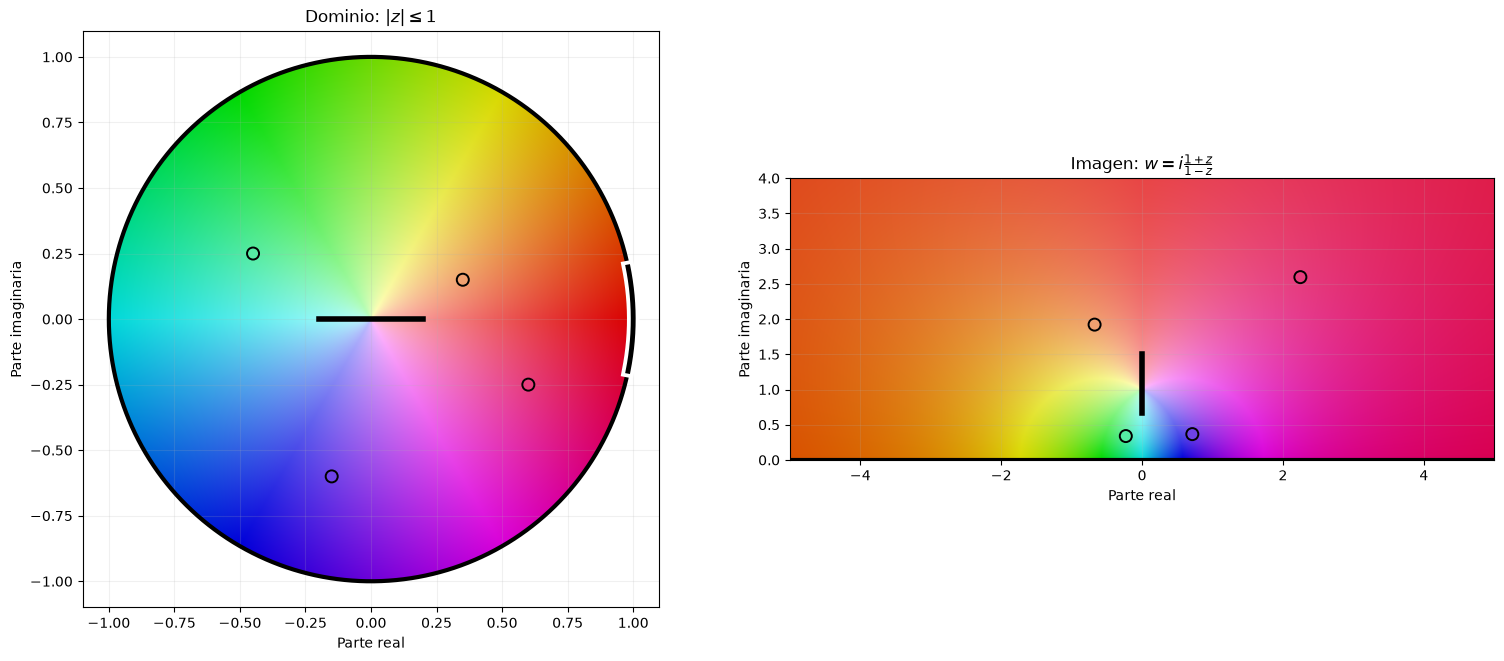

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import hsv_to_rgb


# ============================================================
# 1. Transformación de Cayley y su inversa
# ============================================================

def f(z, tol=1e-12):
    """
    Transformación:
        w = i * (1 + z) / (1 - z)

    El punto z = 1 es una singularidad y se representa mediante NaN.
    """
    z = np.asarray(z, dtype=np.complex128)

    denominator = 1 - z

    result = np.full(
        z.shape,
        np.nan + 1j * np.nan,
        dtype=np.complex128
    )

    np.divide(
        1j * (1 + z),
        denominator,
        out=result,
        where=np.abs(denominator) > tol
    )

    return result.item() if result.ndim == 0 else result


def f_inverse(w):
    """
    Inversa de la transformación de Cayley:

        z = (w - i) / (w + i)
    """
    w = np.asarray(w, dtype=np.complex128)
    return (w - 1j) / (w + 1j)


# ============================================================
# 2. Color asociado a cada punto del disco
# ============================================================

def color_from_z(z):
    """
    El argumento de z determina el tono.
    El módulo de z determina la saturación e intensidad.
    """
    radius = np.clip(np.abs(z), 0, 1)
    angle = np.mod(np.angle(z), 2 * np.pi)

    hue = angle / (2 * np.pi)
    saturation = 0.25 + 0.75 * radius
    value = 1.00 - 0.15 * radius

    hsv = np.stack(
        (hue, saturation, value),
        axis=-1
    )

    return hsv_to_rgb(hsv)


# ============================================================
# 3. Representación
# ============================================================

def plot_cayley_map(
    epsilon=0.20,
    theta0=0.0,
    segment_angle=0.0,
    xlim=None,
    ylim=(0, 12),
    resolution=600
):
    """
    epsilon:
        La línea central tiene longitud 2*epsilon.
        El arco fronterizo también tiene longitud 2*epsilon.

    theta0:
        Centro angular del arco fronterizo.

        theta0 = 0       -> arco centrado en z = 1
        theta0 = pi      -> arco centrado en z = -1

    segment_angle:
        Orientación de la línea central.

        0       -> horizontal
        pi/2    -> vertical
    """

    if not 0 < epsilon < np.pi:
        raise ValueError("epsilon debe satisfacer 0 < epsilon < pi")

    # La imagen del arco alrededor de z=1 llega hasta el infinito.
    # Elegimos automáticamente una escala horizontal suficiente.
    if xlim is None:

        theta0_reduced = abs(
            np.angle(np.exp(1j * theta0))
        )

        if theta0_reduced <= epsilon:
            boundary_value = 1 / np.tan(epsilon / 2)
            horizontal_limit = max(8.0, 1.25 * boundary_value)
        else:
            horizontal_limit = 8.0

        xlim = (-horizontal_limit, horizontal_limit)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6.5),
        constrained_layout=True
    )

    ax_domain, ax_image = axes

    # ========================================================
    # 4. Disco unitario coloreado
    # ========================================================

    x = np.linspace(-1.05, 1.05, resolution)
    y = np.linspace(-1.05, 1.05, resolution)

    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    inside_disk = np.abs(Z) <= 1

    domain_rgba = np.zeros(
        (resolution, resolution, 4)
    )

    domain_rgba[..., :3] = color_from_z(Z)
    domain_rgba[..., 3] = inside_disk.astype(float)

    ax_domain.imshow(
        domain_rgba,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin="lower",
        interpolation="bilinear"
    )

    # ========================================================
    # 5. Semiplano superior coloreado
    #
    # En vez de transformar una malla y dejar que los puntos
    # cercanos a z=1 destruyan la escala, recorremos el plano w
    # y calculamos de qué punto z proviene cada píxel.
    # ========================================================

    nx = resolution

    ny = max(
        300,
        int(
            resolution
            * (ylim[1] - ylim[0])
            / (xlim[1] - xlim[0])
        )
    )

    image_x = np.linspace(xlim[0], xlim[1], nx)
    image_y = np.linspace(ylim[0], ylim[1], ny)

    WX, WY = np.meshgrid(image_x, image_y)
    W = WX + 1j * WY

    Z_preimage = f_inverse(W)

    valid_image = (
        (WY >= 0)
        & (np.abs(Z_preimage) <= 1 + 1e-10)
    )

    image_rgba = np.zeros((ny, nx, 4))

    image_rgba[..., :3] = color_from_z(Z_preimage)
    image_rgba[..., 3] = valid_image.astype(float)

    ax_image.imshow(
        image_rgba,
        extent=[
            xlim[0],
            xlim[1],
            ylim[0],
            ylim[1]
        ],
        origin="lower",
        interpolation="bilinear",
        aspect="auto"
    )

    # ========================================================
    # 6. Contorno completo
    # ========================================================

    theta = np.linspace(0, 2 * np.pi, 2000)
    boundary = np.exp(1j * theta)

    ax_domain.plot(
        boundary.real,
        boundary.imag,
        color="black",
        linewidth=3,
        zorder=5
    )

    # La circunferencia unitaria se transforma en el eje real.
    ax_image.axhline(
        y=0,
        color="black",
        linewidth=3,
        zorder=5
    )

    # ========================================================
    # 7. Arco fronterizo de longitud 2 epsilon
    # ========================================================

    theta_window = np.linspace(
        theta0 - epsilon,
        theta0 + epsilon,
        1600
    )

    z_window = np.exp(1j * theta_window)
    w_window = f(z_window)

    # Arco en el dominio
    ax_domain.plot(
        z_window.real,
        z_window.imag,
        color="white",
        linewidth=9,
        zorder=6
    )

    ax_domain.plot(
        z_window.real,
        z_window.imag,
        color="black",
        linewidth=3.5,
        zorder=7
    )

    # Evitar que Matplotlib una artificialmente las dos ramas
    # que se separan en infinito cuando theta0 = 0.
    horizontal_limit = max(
        abs(xlim[0]),
        abs(xlim[1])
    )

    visible_window = (
        np.isfinite(w_window.real)
        & np.isfinite(w_window.imag)
        & (
            np.abs(w_window.real)
            <= 1.2 * horizontal_limit
        )
        & (w_window.imag >= ylim[0] - 1)
        & (w_window.imag <= ylim[1] + 1)
    )

    w_window_visible = np.where(
        visible_window,
        w_window,
        np.nan + 1j * np.nan
    )

    ax_image.plot(
        w_window_visible.real,
        w_window_visible.imag,
        color="white",
        linewidth=9,
        zorder=6
    )

    ax_image.plot(
        w_window_visible.real,
        w_window_visible.imag,
        color="black",
        linewidth=3.5,
        zorder=7
    )

    # ========================================================
    # 8. Línea de longitud 2 epsilon centrada en el disco
    # ========================================================

    s = np.linspace(-epsilon, epsilon, 800)

    z_segment = s * np.exp(1j * segment_angle)
    w_segment = f(z_segment)

    ax_domain.plot(
        z_segment.real,
        z_segment.imag,
        color="black",
        linewidth=4,
        zorder=8
    )

    ax_image.plot(
        w_segment.real,
        w_segment.imag,
        color="black",
        linewidth=4,
        zorder=8
    )

    # ========================================================
    # 9. Puntos de referencia
    # ========================================================

    z_points = np.array([
        -0.45 + 0.25j,
         0.35 + 0.15j,
         0.60 - 0.25j,
        -0.15 - 0.60j
    ])

    w_points = f(z_points)
    point_colors = color_from_z(z_points)

    ax_domain.scatter(
        z_points.real,
        z_points.imag,
        c=point_colors,
        s=75,
        edgecolors="black",
        linewidths=1.4,
        zorder=10
    )

    visible_points = (
        (w_points.real >= xlim[0])
        & (w_points.real <= xlim[1])
        & (w_points.imag >= ylim[0])
        & (w_points.imag <= ylim[1])
    )

    ax_image.scatter(
        w_points.real[visible_points],
        w_points.imag[visible_points],
        c=point_colors[visible_points],
        s=75,
        edgecolors="black",
        linewidths=1.4,
        zorder=10
    )

    # ========================================================
    # 10. Configuración final
    # ========================================================

    ax_domain.set_xlim(-1.1, 1.1)
    ax_domain.set_ylim(-1.1, 1.1)

    ax_image.set_xlim(*xlim)
    ax_image.set_ylim(*ylim)

    ax_domain.set_aspect("equal", adjustable="box")
    ax_image.set_aspect("equal", adjustable="box")

    for ax in axes:
        ax.set_xlabel("Parte real")
        ax.set_ylabel("Parte imaginaria")
        ax.grid(alpha=0.18)

    ax_domain.set_title(r"Dominio: $|z|\leq 1$")
    ax_image.set_title(
        r"Imagen: $w=i\frac{1+z}{1-z}$"
    )

    return fig, axes


# ============================================================
# 11. Ejecución
# ============================================================

fig, axes = plot_cayley_map(
    epsilon=0.20,

    # El arco está centrado en z = 1.
    # Su imagen aparece en los extremos del eje real.
    theta0=0.0,

    # Segmento horizontal de longitud 2 epsilon.
    segment_angle=0.0,
    xlim=(-5, 5),
    ylim=(0, 4),
    resolution=600
)

plt.show()

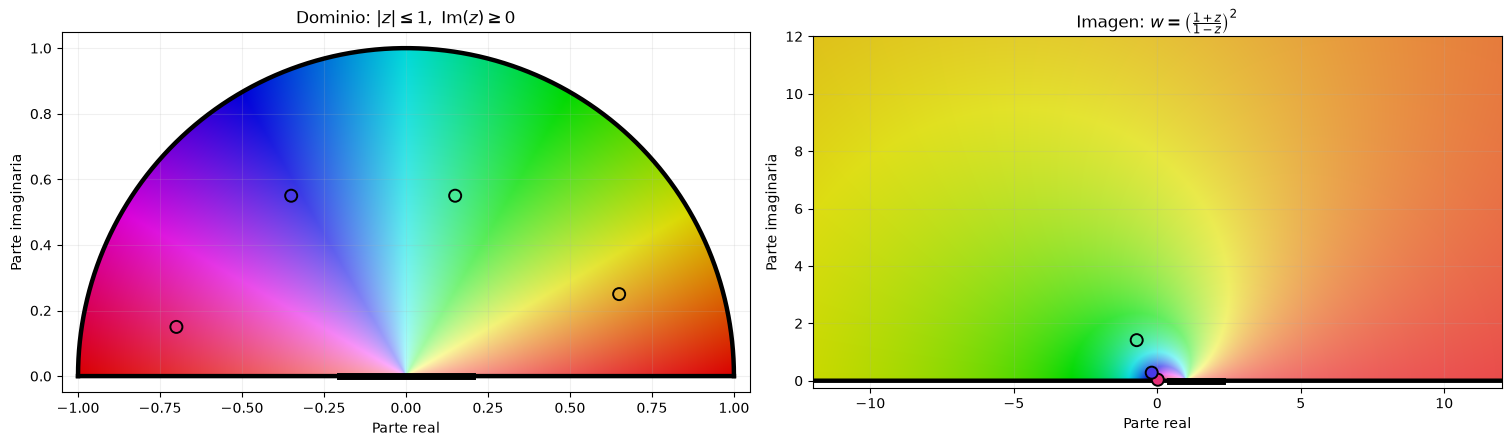

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import hsv_to_rgb


# ============================================================
# 1. Transformación compleja
# ============================================================

def f(z, tol=1e-12):
    """
    w = ((1 + z) / (1 - z))**2

    z = 1 es un polo, por lo que se devuelve NaN en ese punto.
    """
    z = np.asarray(z, dtype=np.complex128)

    numerator = (1 + z)**2
    denominator = (1 - z)**2

    result = np.full(
        z.shape,
        np.nan + 1j*np.nan,
        dtype=np.complex128
    )

    np.divide(
        numerator,
        denominator,
        out=result,
        where=np.abs(1 - z) > tol
    )

    return result.item() if result.ndim == 0 else result


# ============================================================
# 2. Transformación inversa
# ============================================================

def f_inverse(w):
    """
    Si

        w = ((1 + z)/(1 - z))**2,

    entonces, usando la raíz cuadrada principal,

        sqrt(w) = (1 + z)/(1 - z)

    y por tanto

        z = (sqrt(w) - 1)/(sqrt(w) + 1).

    Para Im(w) >= 0, la raíz principal selecciona la rama
    correspondiente al semidisco superior.
    """
    w = np.asarray(w, dtype=np.complex128)

    u = np.sqrt(w)

    return (u - 1) / (u + 1)


# ============================================================
# 3. Color asociado a cada punto z
# ============================================================

def color_from_z(z):
    """
    El argumento de z controla el tono.
    El módulo de z controla saturación e intensidad.
    """
    z = np.asarray(z, dtype=np.complex128)

    radius = np.clip(np.abs(z), 0.0, 1.0)

    # En el semidisco superior, theta pertenece a [0, pi]
    theta = np.clip(np.angle(z), 0.0, np.pi)

    hue = theta / np.pi
    saturation = 0.28 + 0.72*radius
    value = 1.0 - 0.15*radius

    hsv = np.stack(
        (hue, saturation, value),
        axis=-1
    )

    return hsv_to_rgb(hsv)


# ============================================================
# 4. Recortar curvas al área visible
# ============================================================

def visible_curve(w, xlim, ylim):
    """
    Sustituye por NaN los puntos que quedan fuera de la ventana.
    Esto evita líneas artificiales producidas por el recorte.
    """
    w = np.asarray(w, dtype=np.complex128)

    visible = (
        np.isfinite(w.real)
        & np.isfinite(w.imag)
        & (w.real >= xlim[0])
        & (w.real <= xlim[1])
        & (w.imag >= ylim[0])
        & (w.imag <= ylim[1])
    )

    return np.where(
        visible,
        w,
        np.nan + 1j*np.nan
    )


# ============================================================
# 5. Función principal de representación
# ============================================================

def plot_semidisk_map(
    epsilon=0.20,
    resolution=700,
    image_xlim=(-12, 12),
    image_ylim=(-0.25, 12)
):
    """
    Representa el semidisco superior y su imagen por:

        f(z) = ((1 + z)/(1 - z))**2

    epsilon:
        La línea negra centrada en el origen tiene longitud 2*epsilon.

    image_xlim, image_ylim:
        Ventana visible del semiplano superior.
    """

    if not 0 < epsilon < 1:
        raise ValueError("epsilon debe satisfacer 0 < epsilon < 1.")

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6.5),
        constrained_layout=True
    )

    ax_domain, ax_image = axes

    # ========================================================
    # 5.1. Semidisco superior coloreado
    # ========================================================

    x = np.linspace(-1.05, 1.05, resolution)
    y = np.linspace(-0.05, 1.05, resolution // 2)

    X, Y = np.meshgrid(x, y)
    Z = X + 1j*Y

    inside_semidisk = (
        (X**2 + Y**2 <= 1.0)
        & (Y >= 0.0)
    )

    domain_rgba = np.zeros(
        (*Z.shape, 4),
        dtype=float
    )

    domain_rgba[..., :3] = color_from_z(Z)
    domain_rgba[..., 3] = inside_semidisk.astype(float)

    ax_domain.imshow(
        domain_rgba,
        extent=[
            x.min(),
            x.max(),
            y.min(),
            y.max()
        ],
        origin="lower",
        interpolation="bilinear"
    )

    # ========================================================
    # 5.2. Plano de llegada coloreado
    #
    # En lugar de transformar una malla del dominio, tomamos
    # cada píxel w y calculamos su preimagen z.
    # ========================================================

    image_width = resolution

    image_height = max(
        300,
        int(
            image_width
            * (image_ylim[1] - image_ylim[0])
            / (image_xlim[1] - image_xlim[0])
        )
    )

    wx = np.linspace(
        image_xlim[0],
        image_xlim[1],
        image_width
    )

    wy = np.linspace(
        image_ylim[0],
        image_ylim[1],
        image_height
    )

    WX, WY = np.meshgrid(wx, wy)
    W = WX + 1j*WY

    Z_preimage = f_inverse(W)

    valid_image = (
        (WY >= 0.0)
        & (np.abs(Z_preimage) <= 1.0 + 1e-10)
        & (Z_preimage.imag >= -1e-10)
    )

    image_rgba = np.zeros(
        (*W.shape, 4),
        dtype=float
    )

    image_rgba[..., :3] = color_from_z(Z_preimage)
    image_rgba[..., 3] = valid_image.astype(float)

    ax_image.imshow(
        image_rgba,
        extent=[
            image_xlim[0],
            image_xlim[1],
            image_ylim[0],
            image_ylim[1]
        ],
        origin="lower",
        interpolation="bilinear",
        aspect="auto"
    )

    # ========================================================
    # 5.3. Contorno del semidisco
    # ========================================================

    # Arco superior
    theta = np.linspace(0.0, np.pi, 2500)
    z_arc = np.exp(1j*theta)

    # Diámetro
    diameter_x = np.linspace(-1.0, 1.0, 2500)
    z_diameter = diameter_x + 0j

    ax_domain.plot(
        z_arc.real,
        z_arc.imag,
        color="black",
        linewidth=3.2,
        zorder=5
    )

    ax_domain.plot(
        z_diameter.real,
        z_diameter.imag,
        color="black",
        linewidth=3.2,
        zorder=5
    )

    # ========================================================
    # 5.4. Imagen del contorno
    # ========================================================

    # Se evita exactamente z=1 porque allí está el polo.
    gap = 1e-4

    theta_mapped = np.linspace(
        gap,
        np.pi,
        3000
    )

    z_arc_mapped = np.exp(1j*theta_mapped)

    z_diameter_mapped = (
        np.linspace(-1.0, 1.0-gap, 3000)
        + 0j
    )

    w_arc = visible_curve(
        f(z_arc_mapped),
        image_xlim,
        image_ylim
    )

    w_diameter = visible_curve(
        f(z_diameter_mapped),
        image_xlim,
        image_ylim
    )

    ax_image.plot(
        w_arc.real,
        w_arc.imag,
        color="black",
        linewidth=3.2,
        zorder=5
    )

    ax_image.plot(
        w_diameter.real,
        w_diameter.imag,
        color="black",
        linewidth=3.2,
        zorder=5
    )

    # ========================================================
    # 5.5. Segmento de longitud 2 epsilon centrado en el origen
    # ========================================================

    s = np.linspace(-epsilon, epsilon, 1000)

    z_segment = s + 0j
    w_segment = f(z_segment)

    ax_domain.plot(
        z_segment.real,
        z_segment.imag,
        color="black",
        linewidth=5,
        zorder=7
    )

    w_segment_visible = visible_curve(
        w_segment,
        image_xlim,
        image_ylim
    )

    ax_image.plot(
        w_segment_visible.real,
        w_segment_visible.imag,
        color="black",
        linewidth=5,
        zorder=7
    )

    # ========================================================
    # 5.6. Puntos de referencia
    # ========================================================

    z_reference = np.array([
        -0.70 + 0.15j,
        -0.35 + 0.55j,
         0.15 + 0.55j,
         0.65 + 0.25j
    ])

    valid_reference = (
        (np.abs(z_reference) <= 1.0)
        & (z_reference.imag >= 0.0)
    )

    z_reference = z_reference[valid_reference]

    w_reference = f(z_reference)
    reference_colors = color_from_z(z_reference)

    ax_domain.scatter(
        z_reference.real,
        z_reference.imag,
        c=reference_colors,
        s=75,
        edgecolors="black",
        linewidths=1.4,
        zorder=10
    )

    visible_reference = (
        np.isfinite(w_reference.real)
        & np.isfinite(w_reference.imag)
        & (w_reference.real >= image_xlim[0])
        & (w_reference.real <= image_xlim[1])
        & (w_reference.imag >= image_ylim[0])
        & (w_reference.imag <= image_ylim[1])
    )

    ax_image.scatter(
        w_reference.real[visible_reference],
        w_reference.imag[visible_reference],
        c=reference_colors[visible_reference],
        s=75,
        edgecolors="black",
        linewidths=1.4,
        zorder=10
    )

    # ========================================================
    # 5.7. Configuración final
    # ========================================================

    ax_domain.set_xlim(-1.05, 1.05)
    ax_domain.set_ylim(-0.05, 1.05)

    ax_image.set_xlim(*image_xlim)
    ax_image.set_ylim(*image_ylim)

    ax_domain.set_aspect("equal", adjustable="box")
    ax_image.set_aspect("equal", adjustable="box")

    ax_domain.set_title(
        r"Dominio: $|z|\leq1,\ \operatorname{Im}(z)\geq0$"
    )

    ax_image.set_title(
        r"Imagen: $w=\left(\frac{1+z}{1-z}\right)^2$"
    )

    for ax in axes:
        ax.set_xlabel("Parte real")
        ax.set_ylabel("Parte imaginaria")
        ax.grid(alpha=0.18)

    return fig, axes


# ============================================================
# 6. Ejecución
# ============================================================

fig, axes = plot_semidisk_map(
    epsilon=0.20,
    resolution=700,
    image_xlim=(-12, 12),
    image_ylim=(-0.25, 12)
)

plt.show()

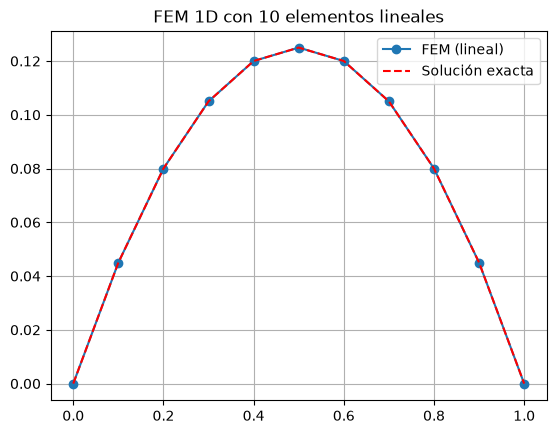

Error máximo en los nodos: 0.000000


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. DATOS DEL PROBLEMA
n_elementos = 10
L = 1.0
h = L / n_elementos  # Tamaño del elemento

# Nodos: de 0 a L, hay n_elementos + 1 nodos
n_nodos = n_elementos + 1
x = np.linspace(0, L, n_nodos)

# 2. INICIALIZAR MATRIZ GLOBAL A (n_nodos x n_nodos) y VECTOR b
A = np.zeros((n_nodos, n_nodos))
b = np.zeros(n_nodos)

# 3. ENSAMBLAJE (el corazón del asunto)
for e in range(n_elementos):  # e = 0, 1, ..., n_elementos-1
    # Índices globales de los nodos de este elemento
    i = e          # nodo izquierdo
    j = e + 1      # nodo derecho

    # Matriz de rigidez local (stiffness) para -u'':
    # (1/h) * [ 1, -1; -1, 1 ]
    A_local = (1.0 / h) * np.array([[1, -1], [-1, 1]])
    
    # Vector de carga local para f(x) = 1 (constante):
    # (h/2) * [1, 1]
    b_local = (h / 2.0) * np.array([1, 1])

    # --- ENSAMBLAJE (sumar en las posiciones globales) ---
    # Fila i, Columna i
    A[i, i] += A_local[0, 0]
    A[i, j] += A_local[0, 1]
    A[j, i] += A_local[1, 0]
    A[j, j] += A_local[1, 1]

    # Vector
    b[i] += b_local[0]
    b[j] += b_local[1]

# 4. IMPONER CONDICIONES DE CONTORNO (Dirichlet: u(0)=0, u(1)=0)
# Método de eliminación (el más limpio conceptualmente):
# Para el nodo 0 (x=0) y nodo n_nodos-1 (x=L):
grados_libres = list(range(1, n_nodos - 1))  # Solo los nodos internos

# Reducimos el sistema a solo los grados de libertad internos
A_reducida = A[np.ix_(grados_libres, grados_libres)]
b_reducida = b[grados_libres]

# 5. RESOLVER SISTEMA LINEAL
u_internos = np.linalg.solve(A_reducida, b_reducida)

# 6. RECONSTRUIR LA SOLUCIÓN COMPLETA (incluyendo bordes)
u = np.zeros(n_nodos)
u[grados_libres] = u_internos

# 7. COMPARAR CON LA SOLUCIÓN ANALÍTICA (para verificar)
# Solución exacta de -u''=1 con bordes 0: u(x) = (x - x^2)/2
u_exacta = (x - x**2) / 2.0

# 8. GRAFICAR
plt.plot(x, u, 'o-', label='FEM (lineal)')
plt.plot(x, u_exacta, 'r--', label='Solución exacta')
plt.legend()
plt.title(f'FEM 1D con {n_elementos} elementos lineales')
plt.grid(True)
plt.show()

# Bonus: Error máximo
error_max = np.max(np.abs(u - u_exacta))
print(f"Error máximo en los nodos: {error_max:.6f}")


<skfem MeshTri1 object>
  Number of elements: 3940
  Number of vertices: 2035
  Number of nodes: 2035
  Named subdomains [# elements]: domain [3940]
  Named boundaries [# facets]: outer [128]
Número total de grados de libertad: 2035
Nodos sobre la frontera exterior: 128
Nodos sobre el electrodo: 24
Valor mínimo de u: 0.00000000
Valor máximo de u: 1.00000000


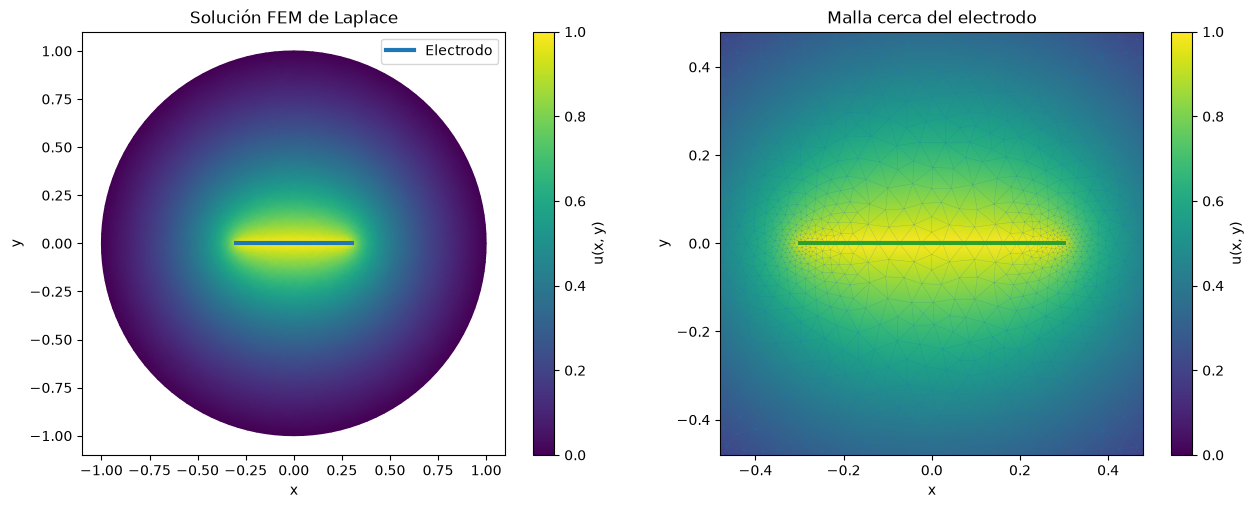

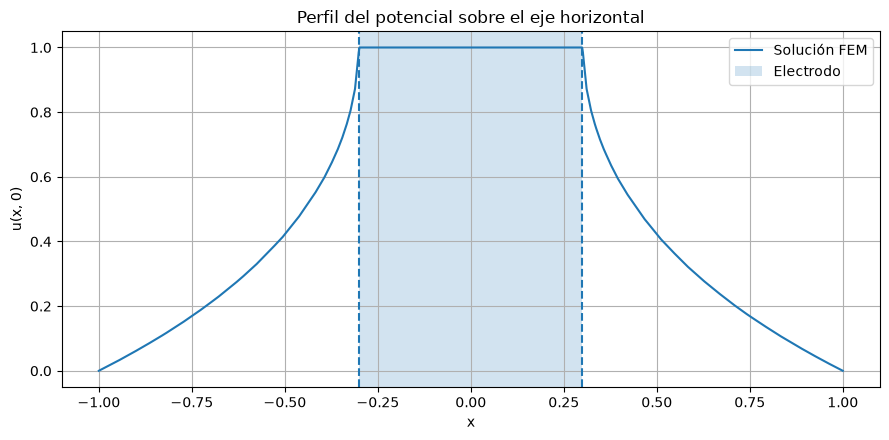

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import tempfile
from pathlib import Path

from skfem import Basis, ElementTriP1, MeshTri
from skfem.models.poisson import laplace
from skfem.utils import condense, solve


# ============================================================================
# 1. PARÁMETROS DEL PROBLEMA
# ============================================================================

R = 1.0
eps = 0.3

mesh_size = 0.05
refine_size = mesh_size / 5.0


# ============================================================================
# 2. GEOMETRÍA Y MALLA CON GMSH
# ============================================================================

geo_content = f"""
SetFactory("Built-in");

// ---------------------------------------------------------------------------
// Disco
// ---------------------------------------------------------------------------

Point(1) = {{0.0, 0.0, 0.0, {mesh_size}}};

Point(2) = {{{R}, 0.0, 0.0, {mesh_size}}};
Point(3) = {{0.0, {R}, 0.0, {mesh_size}}};
Point(4) = {{-{R}, 0.0, 0.0, {mesh_size}}};
Point(5) = {{0.0, -{R}, 0.0, {mesh_size}}};

Circle(1) = {{2, 1, 3}};
Circle(2) = {{3, 1, 4}};
Circle(3) = {{4, 1, 5}};
Circle(4) = {{5, 1, 2}};

Curve Loop(1) = {{1, 2, 3, 4}};
Plane Surface(1) = {{1}};


// ---------------------------------------------------------------------------
// Electrodo interno
// ---------------------------------------------------------------------------

Point(6) = {{-{eps}, 0.0, 0.0, {refine_size}}};
Point(7) = {{{eps}, 0.0, 0.0, {refine_size}}};

Line(5) = {{6, 7}};

// Obliga a que la triangulación sea conforme con el electrodo
Curve{{5}} In Surface{{1}};


// ---------------------------------------------------------------------------
// Grupos físicos
// ---------------------------------------------------------------------------

Physical Curve("outer") = {{1, 2, 3, 4}};
Physical Curve("electrode") = {{5}};
Physical Surface("domain") = {{1}};


// ---------------------------------------------------------------------------
// Refinamiento cerca de los extremos del electrodo
// ---------------------------------------------------------------------------

Field[1] = Distance;
Field[1].PointsList = {{6, 7}};

Field[2] = Threshold;
Field[2].InField = 1;
Field[2].SizeMin = {refine_size};
Field[2].SizeMax = {mesh_size};
Field[2].DistMin = {2.0 * refine_size};
Field[2].DistMax = {4.0 * mesh_size};

Background Field = 2;


// ---------------------------------------------------------------------------
// Opciones de mallado
// ---------------------------------------------------------------------------

Mesh.MeshSizeExtendFromBoundary = 0;
Mesh.MeshSizeFromPoints = 0;
Mesh.MeshSizeFromCurvature = 0;

Mesh.Algorithm = 5;
Mesh.MshFileVersion = 2.2;
"""


with tempfile.TemporaryDirectory() as temporary_directory:

    temporary_directory = Path(temporary_directory)

    geo_filename = temporary_directory / "disk_electrode.geo"
    msh_filename = temporary_directory / "disk_electrode.msh"

    geo_filename.write_text(geo_content, encoding="utf-8")

    result = subprocess.run(
        [
            "gmsh",
            str(geo_filename),
            "-2",
            "-o",
            str(msh_filename)
        ],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:

        print("Salida estándar de Gmsh:")
        print(result.stdout)

        print("Errores de Gmsh:")
        print(result.stderr)

        raise RuntimeError(
            "Gmsh no pudo generar la malla."
        )

    # MeshTri.load usa internamente meshio
    mesh = MeshTri.load(str(msh_filename))


print(mesh)


# ============================================================================
# 3. ESPACIO DE ELEMENTOS FINITOS P1
# ============================================================================

basis = Basis(
    mesh,
    ElementTriP1()
)


# ============================================================================
# 4. PROBLEMA DE LAPLACE
# ============================================================================

# Matriz correspondiente a:
#
# integral_Omega grad(u) · grad(v) dx

A = laplace.assemble(basis)

# No existe fuente volumétrica:
#
# -Delta u = 0

b = np.zeros(basis.N)


# ============================================================================
# 5. GRADOS DE LIBERTAD DE DIRICHLET
# ============================================================================

# Intentamos utilizar los grupos físicos definidos en Gmsh.

try:

    dofs_boundary = basis.get_dofs("outer").all()
    dofs_electrode = basis.get_dofs("electrode").all()

except (KeyError, ValueError):

    # Alternativa robusta si los nombres físicos no fueron importados.

    dofs_boundary = basis.get_dofs().all()

    coordinates = basis.doflocs

    electrode_condition = (
        np.isclose(
            coordinates[1],
            0.0,
            atol=1.0e-10
        )
        &
        (
            np.abs(coordinates[0])
            <= eps + 1.0e-10
        )
    )

    dofs_electrode = np.flatnonzero(
        electrode_condition
    )


if dofs_electrode.size == 0:

    raise RuntimeError(
        "No se encontraron grados de libertad sobre el electrodo. "
        "La curva interna no fue incorporada correctamente a la malla."
    )


# Unión sin índices repetidos

D = np.union1d(
    dofs_boundary,
    dofs_electrode
)


# Vector completo de valores de Dirichlet

u_dirichlet = np.zeros(basis.N)

u_dirichlet[dofs_boundary] = 0.0
u_dirichlet[dofs_electrode] = 1.0


print(f"Número total de grados de libertad: {basis.N}")
print(f"Nodos sobre la frontera exterior: {dofs_boundary.size}")
print(f"Nodos sobre el electrodo: {dofs_electrode.size}")


# ============================================================================
# 6. CONDENSACIÓN Y RESOLUCIÓN
# ============================================================================

u = solve(
    *condense(
        A,
        b,
        D=D,
        x=u_dirichlet
    )
)


print(f"Valor mínimo de u: {u.min():.8f}")
print(f"Valor máximo de u: {u.max():.8f}")


# ============================================================================
# 7. VISUALIZACIÓN DE LA SOLUCIÓN
# ============================================================================

x_values = mesh.p[0]
y_values = mesh.p[1]

triangles = mesh.t.T


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


plot_global = axes[0].tripcolor(
    x_values,
    y_values,
    triangles,
    u,
    shading="gouraud",
    cmap="viridis"
)

axes[0].plot(
    [-eps, eps],
    [0.0, 0.0],
    linewidth=3,
    label="Electrodo"
)

axes[0].set_title("Solución FEM de Laplace")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[0].legend()

fig.colorbar(
    plot_global,
    ax=axes[0],
    label="u(x, y)"
)


zoom = 1.6 * eps

plot_zoom = axes[1].tripcolor(
    x_values,
    y_values,
    triangles,
    u,
    shading="gouraud",
    cmap="viridis"
)

axes[1].triplot(
    x_values,
    y_values,
    triangles,
    linewidth=0.25,
    alpha=0.4
)

axes[1].plot(
    [-eps, eps],
    [0.0, 0.0],
    linewidth=3
)

axes[1].set_xlim(-zoom, zoom)
axes[1].set_ylim(-zoom, zoom)

axes[1].set_title("Malla cerca del electrodo")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

fig.colorbar(
    plot_zoom,
    ax=axes[1],
    label="u(x, y)"
)

plt.tight_layout()
plt.show()


# ============================================================================
# 8. PERFIL INTERPOLADO A LO LARGO DE y = 0
# ============================================================================

# No se buscan nodos exactamente sobre y = 0.
# Se evalúa la función FEM en puntos arbitrarios.

x_line = np.linspace(
    -R + 1.0e-8,
    R - 1.0e-8,
    1000
)

# Desplazamiento numérico mínimo para evitar ambigüedad al evaluar
# exactamente sobre una faceta interna.

y_line = np.full_like(
    x_line,
    1.0e-12
)

points_line = np.vstack([
    x_line,
    y_line
])

u_interpolator = basis.interpolator(u)
u_line = u_interpolator(points_line)


plt.figure(figsize=(9, 4.5))

plt.plot(
    x_line,
    u_line,
    label="Solución FEM"
)

plt.axvspan(
    -eps,
    eps,
    alpha=0.2,
    label="Electrodo"
)

plt.axvline(
    -eps,
    linestyle="--"
)

plt.axvline(
    eps,
    linestyle="--"
)

plt.xlabel("x")
plt.ylabel("u(x, 0)")
plt.title("Perfil del potencial sobre el eje horizontal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()